In [ ]:
import os
import sys
import logging
import optuna
import pandas as pd

from sklearn.metrics import mean_absolute_error


# Add the project root to sys.path if it's not already there
notebook_dir = os.getcwd()
project_root = os.path.abspath(os.path.join(notebook_dir, ".."))
if project_root not in sys.path:
    sys.path.append(project_root)

import src
from utils import plot_actual_vs_predicted

In [ ]:
# Read config
config = src.AppSettings.from_yaml(f'{project_root}/config.yaml')

# Set up logging
os.makedirs(config.path.log_dir, exist_ok=True)
optuna.logging.set_verbosity(optuna.logging.WARNING)
logging.basicConfig(level=logging.INFO,
                    filename=config.path.logs,
                    format="%(levelname)s  %(message)s")

logger = logging.getLogger(__name__)

# Ingest a small subset of data

In [5]:
stores_to_use = [1, 2, 3] # Only train on a subset of stores for the smoke test

sales  = pd.read_csv(config.path.train)
stores = pd.read_csv(config.path.stores)
stores = stores[stores['Store'].isin(stores_to_use)]

df = src.preprocess_data(sales, stores)

C:\Users\m_kal\AppData\Local\Temp\ipykernel_17292\1903625824.py:3: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  sales  = pd.read_csv(config.path.train)


# Feature engineering + target transform

In [6]:
y = df.set_index(['Store', 'Date'])['Sales']

X = (df
     .set_index(['Date'])
     .groupby('Store')
     .apply(lambda df: src.features.compute(df, config.feature_engineering, config.horizon)))

target_horizon = pd.DateOffset(days=-config.horizon.days) # negative offset for forward difference
trf = src.engine.TargetTransformer(forecast_horizon=target_horizon, anchor_col='lag_days_0')
trf.fit(X)

y = trf.transform(y)
X = X.loc[y.index]  # align features with target

for col in X.select_dtypes(include='object').columns:
    X[col] = X[col].astype('category')


C:\Users\m_kal\AppData\Local\Temp\ipykernel_17292\3438955696.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda df: src.features.compute(df, config.feature_engineering, config.horizon)))


# Single-trial smoke test of `_objective`

[0]	train-rmse:4.79615+0.00458	test-rmse:4.73305+0.01345
[100]	train-rmse:4.34292+0.00409	test-rmse:4.28288+0.01134
[200]	train-rmse:3.93287+0.00366	test-rmse:3.87542+0.00973
[300]	train-rmse:3.56199+0.00325	test-rmse:3.50683+0.00837
[400]	train-rmse:3.22642+0.00286	test-rmse:3.17335+0.00729
[500]	train-rmse:2.92291+0.00259	test-rmse:2.87176+0.00647
[600]	train-rmse:2.64839+0.00237	test-rmse:2.59889+0.00600
[700]	train-rmse:2.40017+0.00214	test-rmse:2.35168+0.00558
[800]	train-rmse:2.17567+0.00189	test-rmse:2.12807+0.00535
[900]	train-rmse:1.97270+0.00168	test-rmse:1.92583+0.00520
[1000]	train-rmse:1.78928+0.00143	test-rmse:1.74284+0.00508
[1100]	train-rmse:1.62355+0.00131	test-rmse:1.57723+0.00504
[1200]	train-rmse:1.47393+0.00126	test-rmse:1.42734+0.00494
[1300]	train-rmse:1.33891+0.00113	test-rmse:1.29175+0.00486
[1400]	train-rmse:1.21692+0.00101	test-rmse:1.16896+0.00471
[1500]	train-rmse:1.10700+0.00093	test-rmse:1.05785+0.00463
[1600]	train-rmse:1.00782+0.00087	test-rmse:0.95740+

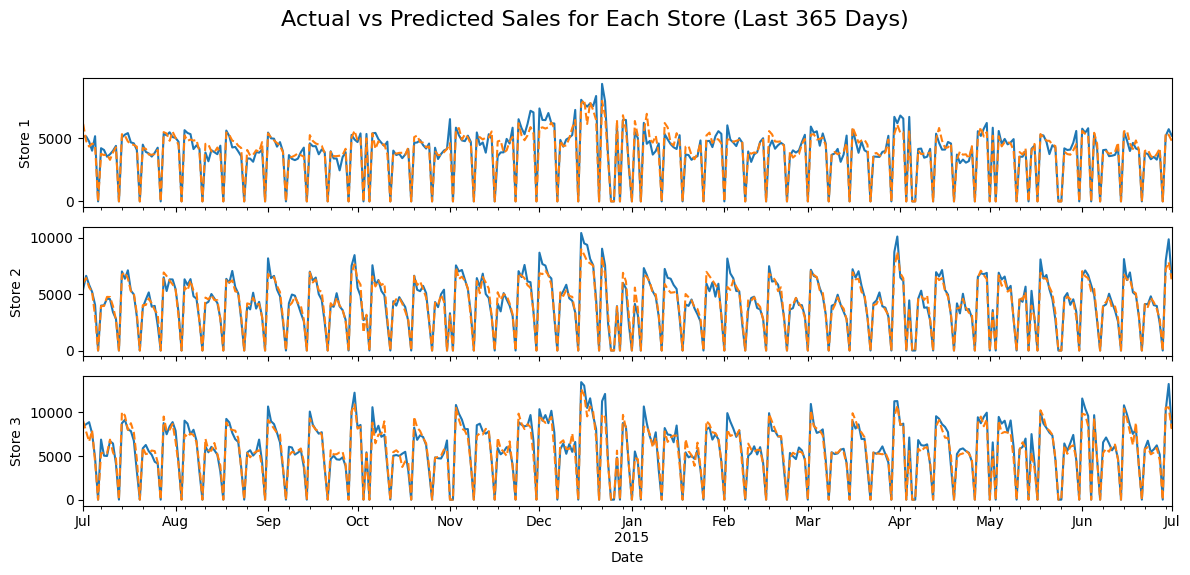

In [7]:
from optuna.trial import FixedTrial
from src.engine.hypertuning import _objective

# Make a fixed trial with specific hyperparameters for testing
params = {
    'max_depth': 6,
    'learning_rate': 1e-3,
    'subsample': 0.7,
    'colsample_bytree': 1.0,
    'min_child_weight': 1,
    'reg_alpha': 0.1,
    'reg_lambda': 0.1,
    'gamma': 0.1,
}
mock_trial = FixedTrial(params)

# Set up cross-validation
num_days = X.index.get_level_values("Date").nunique()
cv_sizes = src.engine.compute_cv_sizes(num_days, config.horizon.days, config.cross_validation)

inner_cv = src.engine.TimeSeriesCV(
    n_splits=config.cross_validation.n_inner_splits,
    gap=config.horizon.days,
    train_size=cv_sizes['inner_train'],
    test_size=cv_sizes['inner_test'])

# Run the objective function with the fixed trial to test it
obj_fcn = lambda trial: _objective(trial, X, y, inner_cv, study_name='test_study', config=config)
obj_fcn(mock_trial)

# Refit on the entire dataset
booster = src.engine.refit(X, y, mock_trial, config.model_constants)
preds   = src.engine.predict(X, booster, trf)

# Get actuals and predictions
actuals = df.set_index(['Store', 'Date'])['Sales']
results = pd.merge(actuals, preds, 
                   left_index=True, right_index=True, 
                   suffixes=('_actual', '_predicted'))
err_mae = mean_absolute_error(results["Sales_actual"], results["Sales_predicted"])

# Show results
print(f"In-train MAE: {err_mae:.2f}")
plot_actual_vs_predicted(results, n_days_to_plot=365, n_days_offset=30)  # This plots in-train predictions. Beware!